# Look at the Gaussian filtered SWOT images (with and without L4 as a background)

In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt

import os
from glob import glob

from cstes import (
    swot_dir,
    drifters_dir,
    get_proj,
    lonlat2xy,
    zarr_dir,
    surface_drifters,
    depth_drifters,
    depth_100,
    depth_50,
    images_dir,
    U2,
    err_acc,
)
from diagnosis import (
    update_dict,
    dataset_coloc_combs,
    dataset_coloc_combs,
    prepared_drifters,
    prepared_wd,
    prepared_alti,
    compute_mean_square,
    compute_mean_square_groupby,
    put_fig_letter,
)

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.geodesic as cgeo

crs = ccrs.PlateCarree()

import cartopy.geodesic as geod
import cartopy.crs as ccrs
import cartopy.feature as cfeature

import pyproj
from pyproj import Geod

from rasterio.transform import Affine

import pynsitu as pyn

from diagnosis import synthetic_figure
from cstes import U2, c0

ModuleNotFoundError: No module named 'pynsitu'

In [ ]:
from swot import browse_swot_250m

dfs = browse_swot_250m().reset_index()
cycle = 500

In [2]:
f2km = glob(
    os.path.join(zarr_dir, "before_coloc", "preprocessed_swot", "swot2km", "*", "*")
)
f2km

['/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/before_coloc/preprocessed_swot/swot2km/gaussian_aviso/pass16_swot2km_gaussian_aviso_50000.nc',
 '/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/before_coloc/preprocessed_swot/swot2km/gaussian_aviso/pass3_swot2km_gaussian_aviso_7000.nc',
 '/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/before_coloc/preprocessed_swot/swot2km/gaussian_aviso/pass16_swot2km_gaussian_aviso_10000.nc',
 '/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/before_coloc/preprocessed_swot/swot2km/gaussian_aviso/pass16_swot2km_gaussian_aviso_35000.nc',
 '/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/before_coloc/preprocessed_swot/swot2km/gaussian_aviso/pass16_swot2km_gaussian_aviso_2000.nc',
 '/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/before_coloc/preprocessed_swot/swot2km/gaussian_aviso/pass3_swot2km_gaussian_aviso_200000.nc',
 '/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/before

In [3]:
f250m = glob(
    os.path.join(zarr_dir, "before_coloc", "preprocessed_swot", "swot250m", "*", "*")
)
f250m

['/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/before_coloc/preprocessed_swot/swot250m/general/3_490.nc',
 '/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/before_coloc/preprocessed_swot/swot250m/general/16_552.nc',
 '/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/before_coloc/preprocessed_swot/swot250m/general/3_560.nc',
 '/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/before_coloc/preprocessed_swot/swot250m/general/3_518.nc',
 '/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/before_coloc/preprocessed_swot/swot250m/general/3_475.nc',
 '/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/before_coloc/preprocessed_swot/swot250m/general/3_504.nc',
 '/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/before_coloc/preprocessed_swot/swot250m/general/3_529.nc',
 '/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/before_coloc/preprocessed_swot/swot250m/general/16_571.nc',
 '/home/datawork-lops-oc/aponte/margot

In [5]:
import scipy.signal.windows as wdw

cutoff = 50
dx = 2
# Gaussian a la mano
lambda_cutoff = cutoff / dx
sigma_cutoff = lambda_cutoff * np.sqrt(np.log(2))
Mg = int(2 * np.round(4 * lambda_cutoff) + 1)
gaussian = wdw.gaussian(Mg, std=sigma_cutoff)

In [6]:
gaussian

array([9.71771230e-06, 1.22267635e-05, 1.53481665e-05, 1.92220190e-05,
       2.40181204e-05, 2.99417061e-05, 3.72401639e-05, 4.62108690e-05,
       5.72102969e-05, 7.06645796e-05, 8.70816943e-05, 1.07065481e-04,
       1.31331707e-04, 1.60726401e-04, 1.96246700e-04, 2.39064460e-04,
       2.90552880e-04, 3.52316405e-04, 4.26224155e-04, 5.14447149e-04,
       6.19499534e-04, 7.44284056e-04, 8.92141948e-04, 1.06690738e-03,
       1.27296654e-03, 1.51532145e-03, 1.79965835e-03, 2.13242063e-03,
       2.52088595e-03, 2.97324729e-03, 3.49869737e-03, 4.10751576e-03,
       4.81115790e-03, 5.62234506e-03, 6.55515393e-03, 7.62510460e-03,
       8.84924522e-03, 1.02462316e-02, 1.18363995e-02, 1.36418283e-02,
       1.56863916e-02, 1.79957952e-02, 2.05975963e-02, 2.35212044e-02,
       2.67978580e-02, 3.04605767e-02, 3.45440834e-02, 3.90846960e-02,
       4.41201841e-02, 4.96895892e-02, 5.58330058e-02, 6.25913221e-02,
       7.00059179e-02, 7.81183202e-02, 8.69698158e-02, 9.66010212e-02,
      

# 250m

0
1
2
3
4
5
6
7
8
9


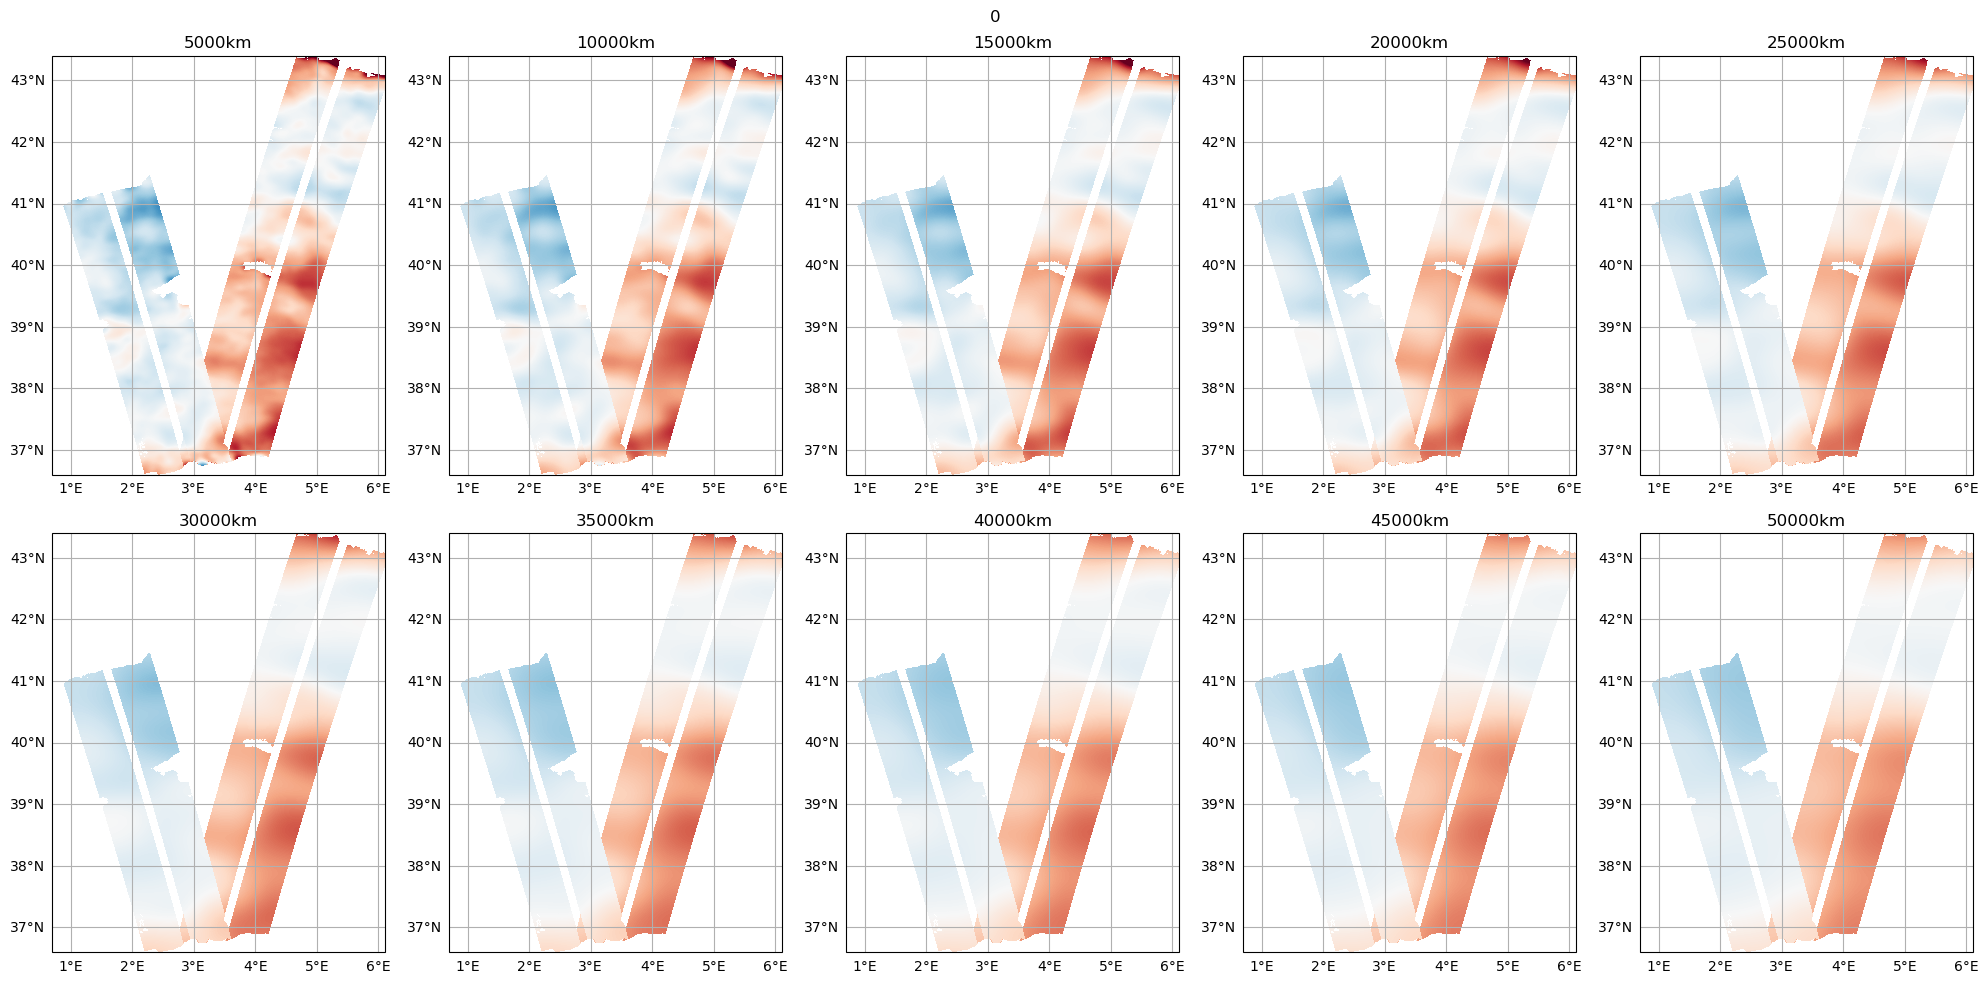

In [22]:
method = "gaussian"
cutoff = np.arange(5e3, 60e3, 5e3)
N = len(cutoff)
kwargs = dict(vmin=-0.2, vmax=0.2, cmap="RdBu_r", add_colorbar=False)

fig, axs = plt.subplots(
    2, 5, figsize=(20, 10), subplot_kw={"projection": ccrs.PlateCarree()}
)
axs = axs.flatten()
for i in range(N - 1):
    ctoff = cutoff[i]
    dss3 = xr.open_dataset(
        f"/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC/before_coloc/preprocessed_swot/swot250m/{method}_{int(ctoff)}/3_{int(cycle)}.nc"
    )
    dss16 = xr.open_dataset(
        f"/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC/before_coloc/preprocessed_swot/swot250m/{method}_{int(ctoff)}/16_{int(cycle)}.nc"
    )
    dss3 = dss3.where(
        (dss3.longitude > bbox[0])
        & (dss3.longitude < bbox[1])
        & (dss3.latitude > bbox[2])
        & (dss3.latitude < bbox[3])
    )
    dss16 = dss16.where(
        (dss16.longitude > bbox[0])
        & (dss16.longitude < bbox[1])
        & (dss16.latitude > bbox[2])
        & (dss16.latitude < bbox[3])
    )
    ax = axs[i]
    dss3.filtered_etaf.plot(x="longitude", y="latitude", ax=ax, transform=crs, **kwargs)
    dss16.filtered_etaf.plot(
        x="longitude", y="latitude", ax=ax, transform=crs, **kwargs
    )
    print(i)
    ax.set_title(f"{int(ctoff)}km")
    gl = ax.gridlines(
        draw_labels=True,
    )
    ax.set_extent(bbox)
    gl.top_labels = False
    gl.right_labels = False
fig.suptitle(f"{int(cycle/1000)}")
fig.tight_layout()

# 2km - with L4 as a back ground

0
1
2
3
4
5
6
7
8
9


Text(0.5, 0.98, 'SWOT cycle = 500')

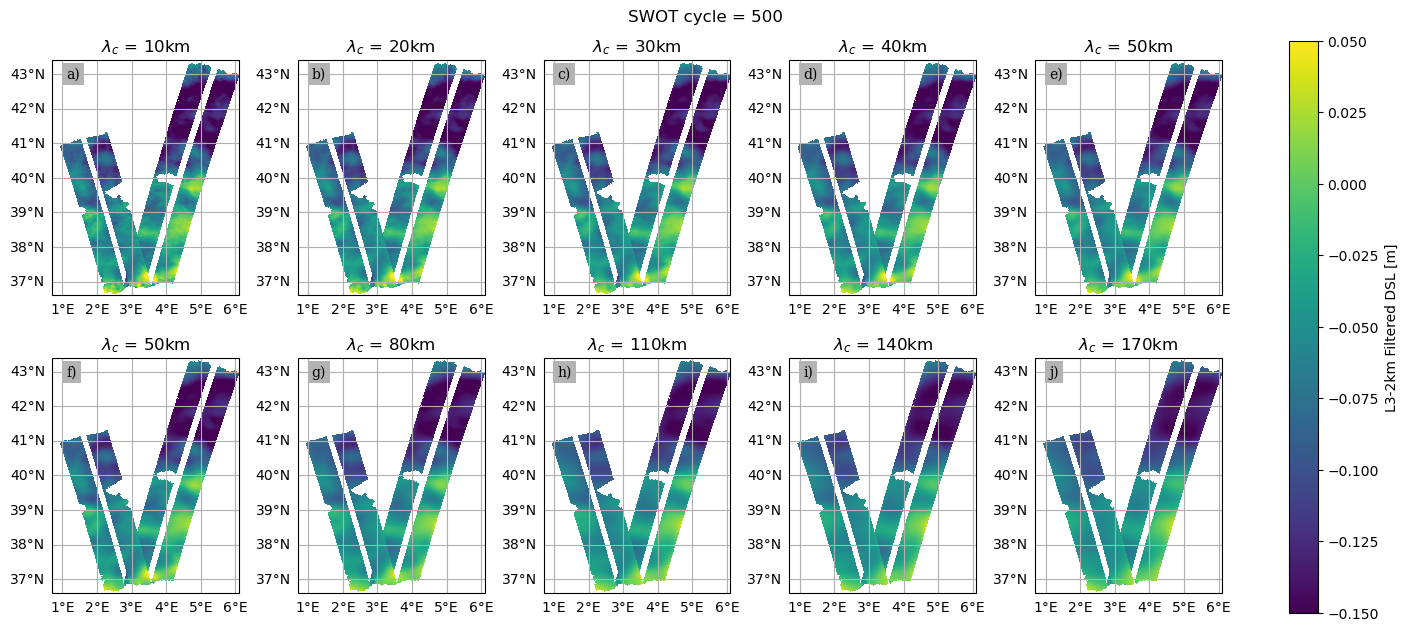

In [9]:
cycle = 500
bbox = [0.7, 6.1, 36.6, 43.4]

method = "gaussian_aviso"
cutoff = list(np.arange(10e3,51e3, 10e3))+list(np.arange(50e3, 201e3, 30e3)) 
N = len(cutoff)
kwargs = dict(
    vmin=-0.15, vmax=0.05, cmap="viridis", add_colorbar=False
)  # cmap ='RdBu_r'

fig, axs = plt.subplots(
    2,
    5,
    figsize=(14, 6.2),
    subplot_kw={"projection": ccrs.PlateCarree()},
    sharex=True,
    sharey=True,
    layout="constrained",
)
axs = axs.flatten()
for i in range(N - 1):
    ctoff = cutoff[i]
    dss3 = xr.open_dataset(
        f"/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/before_coloc/preprocessed_swot/swot2km/{method}/pass3_swot2km_{method}_{int(ctoff)}.nc"
    ).sel(cycle_number=cycle)
    dss16 = xr.open_dataset(
        f"/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/before_coloc/preprocessed_swot/swot2km/{method}/pass16_swot2km_{method}_{int(ctoff)}.nc"
    ).sel(cycle_number=cycle)
    dss3 = dss3.where(
        (dss3.longitude > bbox[0])
        & (dss3.longitude < bbox[1])
        & (dss3.latitude > bbox[2])
        & (dss3.latitude < bbox[3])
    )
    dss16 = dss16.where(
        (dss16.longitude > bbox[0])
        & (dss16.longitude < bbox[1])
        & (dss16.latitude > bbox[2])
        & (dss16.latitude < bbox[3])
    )
    ax = axs[i]
    a = dss3.filtered_etac.assign_attrs({"long_name": "L3-2km Filtered DSL [m]"}).plot(
        x="longitude", y="latitude", ax=ax, transform=crs, **kwargs
    )
    dss16.filtered_etac.plot(
        x="longitude", y="latitude", ax=ax, transform=crs, **kwargs
    )
    print(i)
    ax.set_title(rf"$\lambda_c$ = {int(ctoff/1000)}km")
    gl = ax.gridlines(
        draw_labels=True,
    )
    ax.set_extent(bbox)
    gl.top_labels = False
    gl.right_labels = False

i = 0
for l in ["a", "b", "c", "d", "e", "f", "g", "h", "i", "j"]:
    put_fig_letter(fig, axs[i], l)
    i += 1

fig.colorbar(
    a,
    ax=axs.ravel().tolist(),
    location="right",
    shrink=1,
    label="L3-2km Filtered DSL [m]",
)
fig.suptitle(f"SWOT cycle = {int(cycle)}")
# fig.tight_layout()

0
1
2
3
4
5
6
7
8
9


Text(0.5, 0.98, 'SWOT cycle = 500')

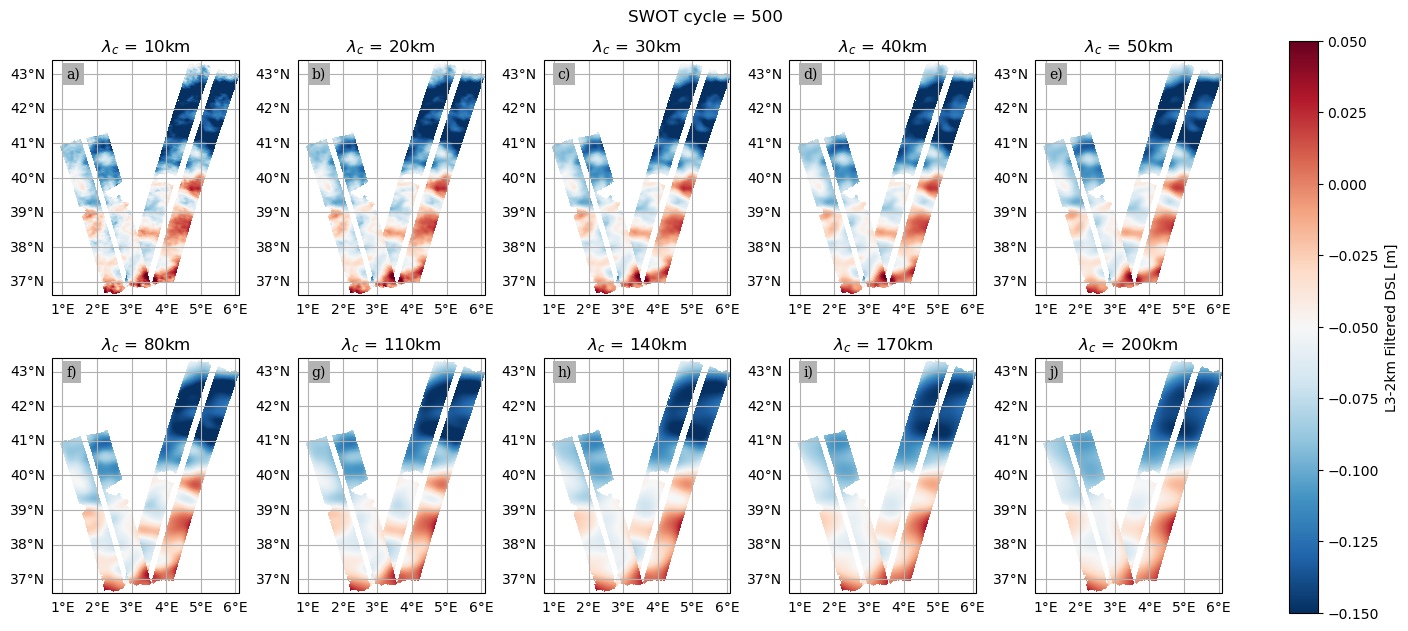

In [19]:
cycle = 500
bbox = [0.7, 6.1, 36.6, 43.4]

method = "gaussian_aviso"
cutoff = list(np.arange(10e3,51e3, 10e3))+list(np.arange(80e3, 251e3, 30e3)) 
N = len(cutoff)
kwargs = dict(
    vmin=-0.15, vmax=0.05, cmap="RdBu_r", add_colorbar=False
)  # cmap ='RdBu_r'

fig, axs = plt.subplots(
    2,
    5,
    figsize=(14, 6.2),
    subplot_kw={"projection": ccrs.PlateCarree()},
    sharex=True,
    sharey=True,
    layout="constrained",
)
axs = axs.flatten()
for i in range(N - 1):
    ctoff = cutoff[i]
    dss3 = xr.open_dataset(
        f"/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/before_coloc/preprocessed_swot/swot2km/{method}/pass3_swot2km_{method}_{int(ctoff)}.nc"
    ).sel(cycle_number=cycle)
    dss16 = xr.open_dataset(
        f"/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/before_coloc/preprocessed_swot/swot2km/{method}/pass16_swot2km_{method}_{int(ctoff)}.nc"
    ).sel(cycle_number=cycle)
    dss3 = dss3.where(
        (dss3.longitude > bbox[0])
        & (dss3.longitude < bbox[1])
        & (dss3.latitude > bbox[2])
        & (dss3.latitude < bbox[3])
    )
    dss16 = dss16.where(
        (dss16.longitude > bbox[0])
        & (dss16.longitude < bbox[1])
        & (dss16.latitude > bbox[2])
        & (dss16.latitude < bbox[3])
    )
    ax = axs[i]
    a = dss3.filtered_etac.assign_attrs(
        {"long_name": "L3-2km Calibrated DSL [m]"}
    ).plot(x="longitude", y="latitude", ax=ax, transform=crs, **kwargs)
    dss16.filtered_etac.plot(
        x="longitude", y="latitude", ax=ax, transform=crs, **kwargs
    )
    print(i)
    ax.set_title(rf"$\lambda_c$ = {int(ctoff/1000)}km")
    gl = ax.gridlines(
        draw_labels=True,
    )
    ax.set_extent(bbox)
    gl.top_labels = False
    gl.right_labels = False

i = 0
for l in ["a", "b", "c", "d", "e", "f", "g", "h", "i", "j"]:
    put_fig_letter(fig, axs[i], l)
    i += 1

fig.colorbar(
    a,
    ax=axs.ravel().tolist(),
    location="right",
    shrink=1,
    label="L3-2km Filtered DSL [m]",
)
fig.suptitle(f"SWOT cycle = {int(cycle)}")
# fig.tight_layout()

In [13]:
40*2*np.pi

251.32741228718345

# Zoom

1
2
3
4
5
6
7
8
9


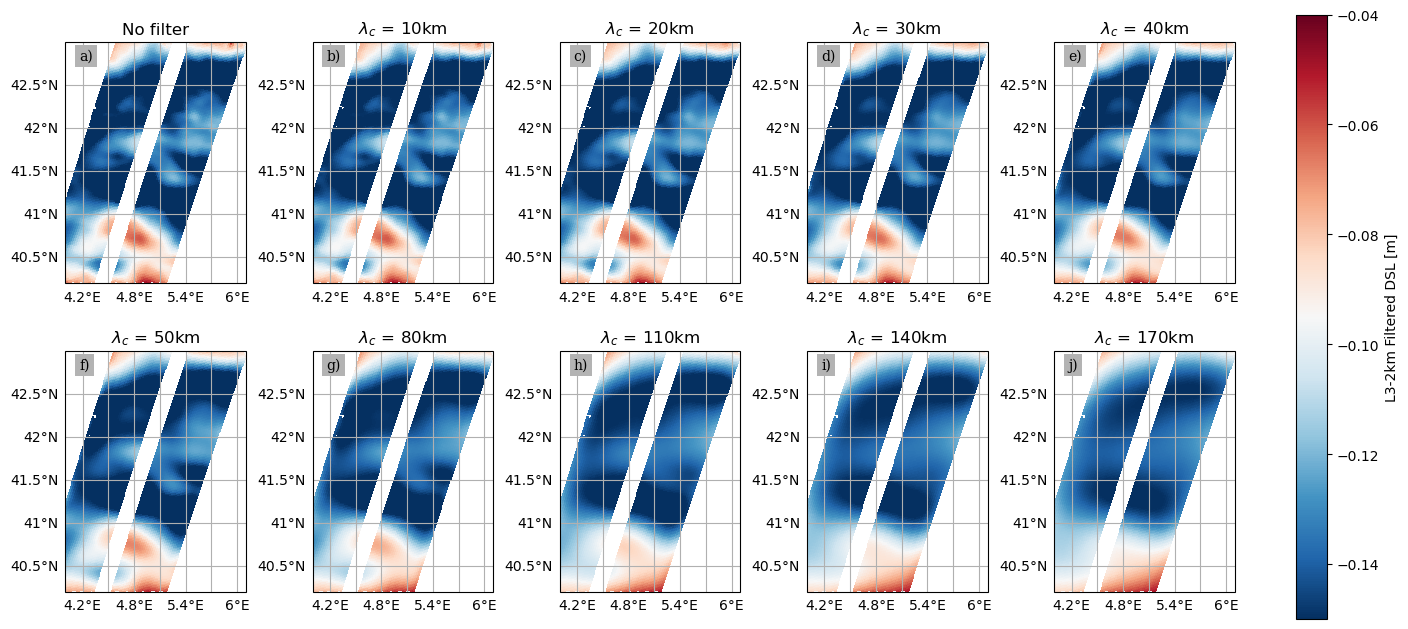

In [17]:
bbox = [4, 6.1, 40.2, 43]
cycle = 500


method = "gaussian_aviso"
cutoff = list(np.arange(10e3,51e3, 10e3))+list(np.arange(80e3, 201e3, 30e3)) 
N = len(cutoff)
kwargs = dict(
    vmin=-0.15, vmax=-0.04, cmap="RdBu_r", add_colorbar=False
)  # cmap ='RdBu_r'

fig, axs = plt.subplots(
    2,
    5,
    figsize=(14, 6.2),
    subplot_kw={"projection": ccrs.PlateCarree()},
    sharex=True,
    sharey=True,
    layout="constrained",
)
axs = axs.flatten()

# No filter
method = "xarray_diff"
dss3 = xr.open_dataset(
    f"/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/before_coloc/preprocessed_swot/swot2km/{method}/pass3_swot2km_{method}.nc"
).sel(cycle_number=cycle)
dss16 = xr.open_dataset(
    f"/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/before_coloc/preprocessed_swot/swot2km/{method}/pass16_swot2km_{method}.nc"
).sel(cycle_number=cycle)
dss3 = dss3.where(
    (dss3.longitude > bbox[0])
    & (dss3.longitude < bbox[1])
    & (dss3.latitude > bbox[2])
    & (dss3.latitude < bbox[3])
)
dss16 = dss16.where(
    (dss16.longitude > bbox[0])
    & (dss16.longitude < bbox[1])
    & (dss16.latitude > bbox[2])
    & (dss16.latitude < bbox[3])
)
ax = axs[0]
a = dss3.etaf.assign_attrs({"long_name": "L3-2km Filtered DSL [m]"}).plot(
    x="longitude", y="latitude", ax=ax, transform=crs, **kwargs
)
dss16.etaf.plot(x="longitude", y="latitude", ax=ax, transform=crs, **kwargs)
ax.set_title("No filter")
gl = ax.gridlines(
    draw_labels=True,
)
ax.set_extent(bbox)
gl.top_labels = False
gl.right_labels = False

# Gaussian
method = "gaussian_aviso"
for i in range(1, N):
    ctoff = cutoff[i - 1]
    dss3 = xr.open_dataset(
        f"/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/before_coloc/preprocessed_swot/swot2km/{method}/pass3_swot2km_{method}_{int(ctoff)}.nc"
    ).sel(cycle_number=cycle)
    dss16 = xr.open_dataset(
        f"/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/before_coloc/preprocessed_swot/swot2km/{method}/pass16_swot2km_{method}_{int(ctoff)}.nc"
    ).sel(cycle_number=cycle)
    dss3 = dss3.where(
        (dss3.longitude > bbox[0])
        & (dss3.longitude < bbox[1])
        & (dss3.latitude > bbox[2])
        & (dss3.latitude < bbox[3])
    )
    dss16 = dss16.where(
        (dss16.longitude > bbox[0])
        & (dss16.longitude < bbox[1])
        & (dss16.latitude > bbox[2])
        & (dss16.latitude < bbox[3])
    )
    ax = axs[i]
    a = dss3.filtered_etaf.assign_attrs({"long_name": "L3-2km Filtered DSL [m]"}).plot(
        x="longitude", y="latitude", ax=ax, transform=crs, **kwargs
    )
    dss16.filtered_etaf.plot(
        x="longitude", y="latitude", ax=ax, transform=crs, **kwargs
    )
    print(i)
    ax.set_title(rf"$\lambda_c$ = {int(ctoff/1000)}km")
    gl = ax.gridlines(
        draw_labels=True,
    )
    ax.set_extent(bbox)
    gl.top_labels = False
    gl.right_labels = False

i = 0
for l in ["a", "b", "c", "d", "e", "f", "g", "h", "i", "j"]:
    put_fig_letter(fig, axs[i], l)
    i += 1

fig.colorbar(
    a,
    ax=axs.ravel().tolist(),
    location="right",
    shrink=1,
    label="L3-2km Filtered DSL [m]",
)
# fig.suptitle(f'SWOT cycle = {int(cycle)}')
# fig.tight_layout()

0
1
2
3
4
5
6
7
8


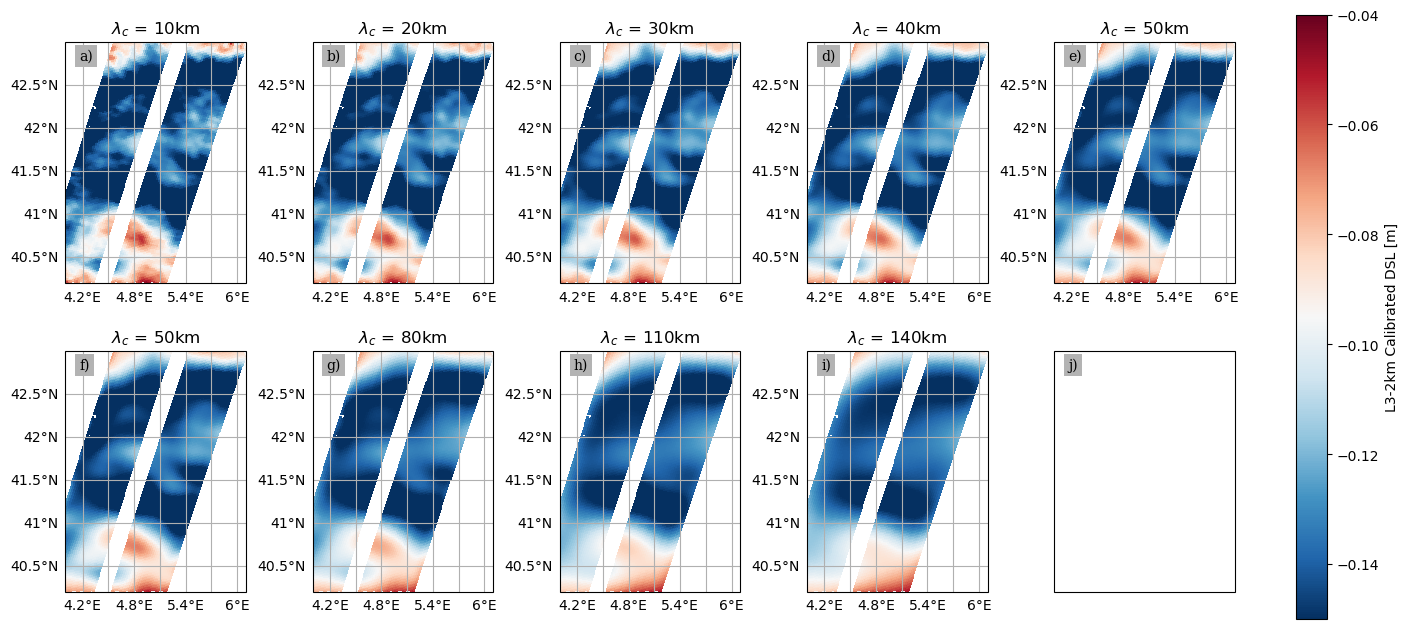

In [14]:
bbox = [4, 6.1, 40.2, 43]
cycle = 500


method = "gaussian_aviso"
cutoff = list(np.arange(10e3,51e3, 10e3))+list(np.arange(50e3, 181e3, 30e3)) 
N = len(cutoff)
kwargs = dict(
    vmin=-0.15, vmax=-0.04, cmap="RdBu_r", add_colorbar=False
)  # cmap ='RdBu_r'

fig, axs = plt.subplots(
    2,
    5,
    figsize=(14, 6.2),
    subplot_kw={"projection": ccrs.PlateCarree()},
    sharex=True,
    sharey=True,
    layout="constrained",
)
axs = axs.flatten()
for i in range(N - 1):
    ctoff = cutoff[i]
    dss3 = xr.open_dataset(
        f"/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/before_coloc/preprocessed_swot/swot2km/{method}/pass3_swot2km_{method}_{int(ctoff)}.nc"
    ).sel(cycle_number=cycle)
    dss16 = xr.open_dataset(
        f"/home/datawork-lops-oc/aponte/margot/DATA_MED_COLOC_v2.0.1/before_coloc/preprocessed_swot/swot2km/{method}/pass16_swot2km_{method}_{int(ctoff)}.nc"
    ).sel(cycle_number=cycle)
    dss3 = dss3.where(
        (dss3.longitude > bbox[0])
        & (dss3.longitude < bbox[1])
        & (dss3.latitude > bbox[2])
        & (dss3.latitude < bbox[3])
    )
    dss16 = dss16.where(
        (dss16.longitude > bbox[0])
        & (dss16.longitude < bbox[1])
        & (dss16.latitude > bbox[2])
        & (dss16.latitude < bbox[3])
    )
    ax = axs[i]
    a = dss3.filtered_etac.assign_attrs(
        {"long_name": "L3-2km Calibrated DSL [m]"}
    ).plot(x="longitude", y="latitude", ax=ax, transform=crs, **kwargs)
    dss16.filtered_etac.plot(
        x="longitude", y="latitude", ax=ax, transform=crs, **kwargs
    )
    print(i)
    ax.set_title(rf"$\lambda_c$ = {int(ctoff/1000)}km")
    gl = ax.gridlines(
        draw_labels=True,
    )
    ax.set_extent(bbox)
    gl.top_labels = False
    gl.right_labels = False

i = 0
for l in ["a", "b", "c", "d", "e", "f", "g", "h", "i", "j"]:
    put_fig_letter(fig, axs[i], l)
    i += 1

fig.colorbar(
    a,
    ax=axs.ravel().tolist(),
    location="right",
    shrink=1,
    label="L3-2km Calibrated DSL [m]",
)
# fig.suptitle(f'SWOT cycle = {int(cycle)}')
# fig.tight_layout()